<a href="https://colab.research.google.com/github/minamoqadasi/object-detection-CIFAR10/blob/main/object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import sys
import numpy as np

from matplotlib import pyplot as plt
from keras.datasets import cifar10
from keras.utils import to_categorical
from keras.models import Sequential
from keras.layers import Conv2D, Input, MaxPooling2D, Dense, Flatten, Dropout, BatchNormalization
from keras.optimizers import SGD, Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator

In [ ]:
### Get cats and dogs images from CIFAR10

In [ ]:
# load, train and test
def load_dataset():
    # load dataset
    (trainX, trainY), (testX, testY) = cifar10.load_data()

    trainY = to_categorical(trainY, 10)
    testY = to_categorical(testY, 10)

    trainX, testX = image_preprocess(trainX, testX)

    # Normalize & Standardize features
    trainX_prep, testX_prep = image_preprocess(trainX, testX)

    return trainX_prep, trainY, testX_prep, testY

In [ ]:
### Preprocessing steps and load data

In [ ]:
# Scale pixels
def image_preprocess(train, test):
    # convert the int to float
    train_norm = train.astype('float32')
    test_norm = test.astype('float32')

    # normalize to range
    train_norm = train_norm / 255.0
    test_norm = test_norm / 255.0

    # mean and std
    mean = np.mean(train_norm, axis=(0, 1, 2), keepdims=True)
    std = np.std(train_norm, axis=(0, 1, 2), keepdims=True) + 1e-7

    # standardize
    train_norm = (train_norm - mean) / std
    test_norm = (test_norm - mean) / std

    # return
    return train_norm, test_norm

In [ ]:
### Model architecture

In [ ]:
def build_cifar10_cnn():
    model = Sequential([
        # Input Layer
        Input(shape=(32, 32, 3)),

        # Block 1
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(32, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.2),

        # Block 2
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.3),

        # Block 3
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D((2, 2)),
        Dropout(0.4),

        # Classifier Head
        Flatten(),
        Dense(128, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),

        # 10 output units matching categorical_crossentropy loss
        Dense(10, activation='softmax')
    ])

    # Optimizer & Compilation
    opt = Adam(learning_rate=0.001)
    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',  # Matches 2D one-hot encoded target shape
        metrics=['accuracy']
    )

    return model

In [ ]:
# load data
(trainX_raw, trainY_raw), (testX_raw, testY_raw) = cifar10.load_data()

# Filter for cat (index 3) and dog (index 5) classes
cat_dog_classes = [3, 5]

train_filter = np.isin(trainY_raw, cat_dog_classes).flatten()
test_filter = np.isin(testY_raw, cat_dog_classes).flatten()

trainX = trainX_raw[train_filter]
trainY = trainY_raw[train_filter]
testX = testX_raw[test_filter]
testY = testY_raw[test_filter]

# Remap labels: cat (3) to 0, dog (5) to 1
# Ensure these are applied to the filtered Y arrays
trainY[trainY == 3] = 0
trainY[trainY == 5] = 1
testY[testY == 3] = 0
testY[testY == 5] = 1

# prepare pixel data (normalize and standardize)
trainX, testX = image_preprocess(trainX, testX)

# Convert labels to categorical with 2 classes
trainY = to_categorical(trainY, 2)
testY = to_categorical(testY, 2)

# Create data generator and iterator
datagen = ImageDataGenerator(
    width_shift_range = 0.1,
    height_shift_range = 0.1,
    horizontal_flip = True
)
it_train = datagen.flow(trainX, trainY, batch_size = 32)

In [ ]:
### Define the model (in this case it is a single layer perceptron)

In [ ]:
def model_perceptron():

    model = Sequential()

    # Input & Flatten
    model.add(Input(shape=(32, 32, 3)))
    model.add(Flatten())

    # Hidden Dense Layers
    model.add(Dense(128, activation='relu', kernel_initializer='he_uniform'))
    model.add(Dense(64, activation='relu', kernel_initializer='he_uniform'))

    # Final Output Layer (MUST be 2 units + softmax for 2 classes)
    model.add(Dense(2, activation='softmax')) # Changed from 10 to 2

    # Compile
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [ ]:
if testX.ndim != 4:
    testX = testX.reshape(-1, 32, 32, 3)

# The following line was redundant as image_preprocess already handles this.
# testX = testX.astype('float32') / 255.0

# Print the correct shapes after filtering and one-hot encoding
print("testX shape:", testX.shape)
print("testY shape:", testY.shape)

testX shape: (2000, 32, 32, 3)
testY shape: (2000, 2)


In [ ]:
### Train the model and execute

In [ ]:
# load PERCEPTRON (ensure the 2-output model is loaded)
model = model_perceptron()

# fit model
steps = int(trainX.shape[0] / 64)

# execute
history = model.fit(it_train, steps_per_epoch = steps, epochs = 100, validation_data = (testX, testY), verbose = 1)

Epoch 1/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 26ms/step - accuracy: 0.5591 - loss: 0.9689 - val_accuracy: 0.5825 - val_loss: 0.7990
Epoch 2/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5681 - loss: 0.7723 - val_accuracy: 0.5935 - val_loss: 0.7337
Epoch 3/100
  1/156 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5625 - loss: 0.8208

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.5625 - loss: 0.8208 - val_accuracy: 0.5965 - val_loss: 0.7340
Epoch 4/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 29ms/step - accuracy: 0.5740 - loss: 0.7564 - val_accuracy: 0.5775 - val_loss: 0.7140
Epoch 5/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - accuracy: 0.5863 - loss: 0.7116 - val_accuracy: 0.5835 - val_loss: 0.6724
Epoch 6/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.4062 - loss: 0.7348 - val_accuracy: 0.5840 - val_loss: 0.6715
Epoch 7/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - accuracy: 0.5938 - loss: 0.6678 - val_accuracy: 0.6030 - val_loss: 0.6772
Epoch 8/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - accuracy: 0.5973 - loss: 0.6659 - val_accuracy: 0.5975 - val_loss: 0.6641
Epoch 9/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.6250 - loss: 0.5952 - val_accuracy: 0.6040 - val_loss: 0.6631
Epoch 10/100
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 25ms/step - accuracy: 0.5996 - loss: 0.6667 - val_accuracy: 

In [ ]:
### Evaluate

In [ ]:
acc = model.evaluate(testX, testY, verbose = 0)
print()
print('Model Accuracy: > %.3f' % (acc[1] * 100.0))


Model Accuracy: > 65.500


In [ ]:
### Predictions

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step


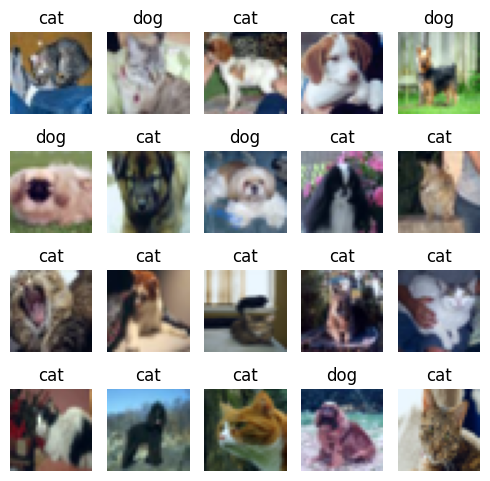

In [ ]:
# predict the first 20 images
predictions = model.predict(testX[0:20])

# Define class names for cat and dog
class_names = ['cat', 'dog']

# create a figure with 20 subplots
fig, axes = plt.subplots(4, 5, figsize = (5,5))

# iterate through the first 20 images and display them with predicted labels
for i, ax in enumerate(axes.flat):
    # Rescale image data to [0, 1] for correct display by imshow
    img = testX[i]
    img_rescaled = (img - img.min()) / (img.max() - img.min())
    ax.imshow(img_rescaled)

    # Get the predicted class index (0 or 1) using argmax
    predicted_class_idx = np.argmax(predictions[i])
    # Get the predicted class name
    predicted_label = class_names[predicted_class_idx]
    ax.set_title(predicted_label)
    ax.set_axis_off()

# add space
plt.tight_layout()

# show plot
plt.show()